In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import copy

# Herramientas de Sklearn para el Grid Search y métricas
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Importes de PyTorch (asumiendo que usas PyTorch por tus libretas anteriores)
import torch
import torch.nn as nn
import torch.optim as optim

from src.learning.models import PINNEmbrittlement, pinn_loss

# Fijar semillas para reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

In [2]:
# Cargar el dataset original
ruta_datos = "../data/df_plotter_cm2.csv"
df = pd.read_csv(ruta_datos)

print(f"Dimensiones del dataset original: {df.shape}")
df.head()

Dimensiones del dataset original: (1889, 8)


,Product_Form,Cu,Ni,Mn,P,Temperature_Celsius,DT41J_Celsius,Fluence_n_cm2
0,F,0.04,0.74,0.6,0.012,287.0,24.888889,4.619000e+18
1,F,0.04,0.74,0.6,0.012,287.0,19.277778,4.619000e+18
2,F,0.04,0.74,0.6,0.012,287.0,38.611111,4.385000e+19
3,F,0.04,0.74,0.6,0.012,287.0,12.833333,4.385000e+19
4,W,0.03,0.56,1.4,0.005,287.0,4.388889,4.619000e+18


Datos de Entrenamiento (Baja/Media Fluencia): 1416 muestras
Datos de Test (Alta Fluencia): 473 muestras


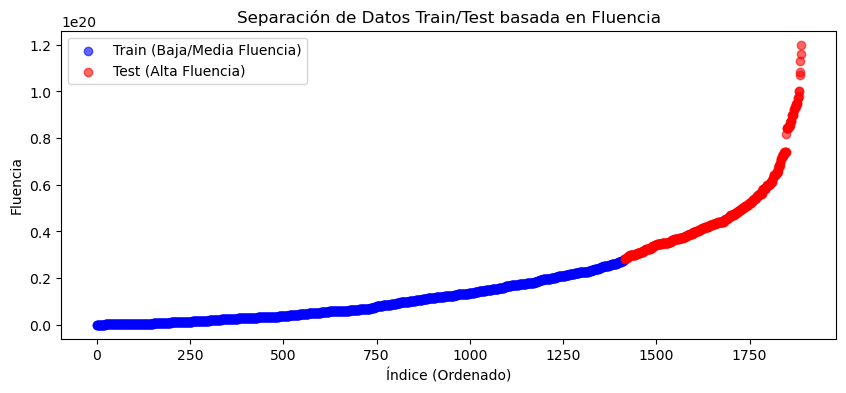

In [3]:
# 1. Ordenar explícitamente por Fluencia (asegúrate de que el nombre de la columna sea el correcto)
columna_fluencia = 'Fluence_n_cm2' # <-- CAMBIA ESTO SI SE LLAMA DISTINTO (ej. 'Fluence', 'Phi')
df_sorted = df.sort_values(by=columna_fluencia, ascending=True).reset_index(drop=True)

# 2. Definir el porcentaje de test (ej. 20%)
test_size = 0.25
split_idx = int(len(df_sorted) * (1 - test_size))

# 3. Dividir los datos
train_df = df_sorted.iloc[:split_idx].copy()
test_df = df_sorted.iloc[split_idx:].copy()

print(f"Datos de Entrenamiento (Baja/Media Fluencia): {len(train_df)} muestras")
print(f"Datos de Test (Alta Fluencia): {len(test_df)} muestras")

# Opcional: Visualizar la separación
plt.figure(figsize=(10, 4))
plt.scatter(train_df.index, train_df[columna_fluencia], label='Train (Baja/Media Fluencia)', color='blue', alpha=0.6)
plt.scatter(test_df.index, test_df[columna_fluencia], label='Test (Alta Fluencia)', color='red', alpha=0.6)
plt.xlabel('Índice (Ordenado)')
plt.ylabel('Fluencia')
plt.title('Separación de Datos Train/Test basada en Fluencia')
plt.legend()
plt.show()

In [4]:
# 1. Mapear Product_Form a valores numéricos (F=0, P=1, W=2) como espera tu fórmula física
mapeo_pf = {'F': 0.0, 'P': 1.0, 'W': 2.0}
train_df['Product_Form'] = train_df['Product_Form'].map(mapeo_pf)
test_df['Product_Form'] = test_df['Product_Form'].map(mapeo_pf)

# 2. Definir TODAS las columnas en el orden EXACTO que espera models.py (Target en el índice 6)
todas_las_columnas = ['Product_Form', 'Cu', 'Ni', 'Mn', 'P', 'Temperature_Celsius', 'DT41J_Celsius', 'Fluence_n_cm2']
caracteristicas = ['Product_Form', 'Cu', 'Ni', 'Mn', 'P', 'Temperature_Celsius', 'Fluence_n_cm2']
target = 'DT41J_Celsius'

# 3. Escalar TODOS los datos juntos (ajustando SOLO en train) para que el preprocessor tenga 8 dimensiones
scaler_completo = StandardScaler()
train_scaled_array = scaler_completo.fit_transform(train_df[todas_las_columnas])
test_scaled_array = scaler_completo.transform(test_df[todas_las_columnas])

# Los volvemos a pasar a DataFrame para extraer X e Y más fácilmente
train_scaled_df = pd.DataFrame(train_scaled_array, columns=todas_las_columnas)
test_scaled_df = pd.DataFrame(test_scaled_array, columns=todas_las_columnas)

# 4. Extraer X e Y ya escalados y convertirlos a tensores
X_train_tensor = torch.tensor(train_scaled_df[caracteristicas].values, dtype=torch.float32)
y_train_tensor = torch.tensor(train_scaled_df[target].values, dtype=torch.float32).reshape(-1, 1)

X_test_tensor = torch.tensor(test_scaled_df[caracteristicas].values, dtype=torch.float32)
y_test_tensor = torch.tensor(test_scaled_df[target].values, dtype=torch.float32).reshape(-1, 1)

# Renombramos el scaler para que lo pueda usar el bucle que ya tienes programado
scaler_X = scaler_completo

In [5]:
# Definimos el espacio de búsqueda (mantenlo pequeño para que no tarde demasiado)
param_grid = {
    'hidden_dim': [16, 32, 64],
    'lr': [0.001, 0.005, 0.01],
    'lambda_física': [0.1, 0.5, 1.0] # El peso de la ecuación física en tu pérdida
}

# Usamos ParameterGrid de sklearn para crear todas las combinaciones posibles
grid = ParameterGrid(param_grid)
best_rmse = float('inf')
best_params = None

print(f"Total de combinaciones a evaluar: {len(grid)}\n")

# Extraemos la dimensión de entrada de los datos
input_dim = X_train_tensor.shape[1]
num_epochs = 300 # Número de épocas fijo para cada entrenamiento del Grid Search

for params in grid:
    print(f"Probando configuración: {params}...")
    
    # =================================================================
    # 1. INICIALIZACIÓN DEL MODELO Y OPTIMIZADOR CON LOS PARÁMETROS ACTUALES
    # =================================================================
    model = PINNEmbrittlement(
        input_dim=input_dim, 
        hidden_dim=params['hidden_dim'], # Lo toma del Grid
        num_layers=3,                    # Fijo por ahora (puedes cambiarlo)
        activation=nn.SiLU,              # Fijo
        preprocessor=scaler_X
    )
    
    optimizer = optim.Adam(model.parameters(), lr=params['lr']) # Lo toma del Grid
    
    # =================================================================
    # 2. BUCLE DE ENTRENAMIENTO
    # =================================================================
    model.train()
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        
        # Necesitamos habilitar gradientes en la entrada para la pérdida física
        X_train_tensor.requires_grad_(True)
        
        # Calculamos la pérdida usando la función de tu PINN
        # (Asegúrate de que fluence_idx es correcto. Asumo que es el 5)
        loss, loss_data, loss_fisica = pinn_loss(
            model, 
            X_train_tensor, 
            y_train_tensor, 
            fluence_idx=6, 
            lambda_data=1.0, 
            lambda_mono=params['lambda_física'] # Lo toma del Grid
        )
        
        loss.backward()
        optimizer.step()
        
    # =================================================================
    # 3. EVALUACIÓN EN EL TEST SET (ALTAS FLUENCIAS)
    # =================================================================
    model.eval()
    with torch.no_grad():
        preds_test_scaled = model(X_test_tensor).numpy()
        
        # --- NUEVO: Desescalamos las predicciones ---
        # El target ('DT41J_Celsius') está en el índice 6 de nuestro scaler_completo
        mean_y = scaler_completo.mean_[6]
        scale_y = scaler_completo.scale_[6]
        
        preds_test_real = (preds_test_scaled * scale_y) + mean_y
        
        # Cogemos los valores reales directamente del dataframe original (sin escalar)
        y_test_real = test_df[target].values.reshape(-1, 1)
        
        # Calculamos el RMSE en GRADOS CELSIUS
        rmse_actual = np.sqrt(mean_squared_error(y_test_real, preds_test_real))
    
    print(f"-> RMSE en Altas Fluencias: {rmse_actual:.3f} °C\n")
        
    # =================================================================
    # 4. GUARDAR EL MEJOR MODELO
    # =================================================================
    if rmse_actual < best_rmse:
        best_rmse = rmse_actual
        best_params = params
        best_model_state = copy.deepcopy(model.state_dict())

print("="*50)
print(f"🏆 MEJORES PARÁMETROS ENCONTRADOS: {best_params}")
print(f"🎯 MEJOR RMSE EN EXTRAPOLACIÓN (Altas Fluencias): {best_rmse:.3f} °C")
print("="*50)
print("="*50)

Total de combinaciones a evaluar: 27

Probando configuración: {'hidden_dim': 16, 'lambda_física': 0.1, 'lr': 0.001}...
-> RMSE en Altas Fluencias: 16.240 °C

Probando configuración: {'hidden_dim': 16, 'lambda_física': 0.1, 'lr': 0.005}...
-> RMSE en Altas Fluencias: 22.648 °C

Probando configuración: {'hidden_dim': 16, 'lambda_física': 0.1, 'lr': 0.01}...
-> RMSE en Altas Fluencias: 20.864 °C

Probando configuración: {'hidden_dim': 16, 'lambda_física': 0.5, 'lr': 0.001}...
-> RMSE en Altas Fluencias: 19.715 °C

Probando configuración: {'hidden_dim': 16, 'lambda_física': 0.5, 'lr': 0.005}...
-> RMSE en Altas Fluencias: 48.462 °C

Probando configuración: {'hidden_dim': 16, 'lambda_física': 0.5, 'lr': 0.01}...
-> RMSE en Altas Fluencias: 19.902 °C

Probando configuración: {'hidden_dim': 16, 'lambda_física': 1.0, 'lr': 0.001}...
-> RMSE en Altas Fluencias: 18.959 °C

Probando configuración: {'hidden_dim': 16, 'lambda_física': 1.0, 'lr': 0.005}...
-> RMSE en Altas Fluencias: 23.696 °C

Prob

In [5]:
# Desescalamos las predicciones del MEJOR modelo encontrado
mejor_modelo = PINNEmbrittlement(
    input_dim=X_train_tensor.shape[1], 
    hidden_dim=best_params['hidden_dim'], 
    num_layers=3, 
    activation=nn.SiLU, 
    preprocessor=scaler_completo # Usamos el scaler completo
)

os.makedirs("../models", exist_ok=True)

if best_model_state is not None:
    mejor_modelo.load_state_dict(best_model_state)
    print("✅ Pesos del modelo entrenado cargados correctamente.")

# Guardar los pesos de la PINN de Extrapolación
ruta_modelo_05 = "../models/05_pinn_extrapolacion.pth"
torch.save(mejor_modelo.state_dict(), ruta_modelo_05)

print(f"Modelo PINN de Extrapolación guardado correctamente en: {ruta_modelo_05}")

# Aseguramos de que tenemos los valores reales de test
y_test_real = test_df[target].values.reshape(-1, 1)

# Asumiendo que 'preds_test_real' guarda la mejor predicción (o recálculala)
plt.figure(figsize=(8, 6))
plt.scatter(y_test_real, preds_test_real, color='dodgerblue', alpha=0.7, edgecolors='k', s=50, label='Predicciones PINN')

# Línea Ideal (Identidad)
max_val = max(y_test_real.max(), preds_test_real.max())
min_val = min(y_test_real.min(), preds_test_real.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Comportamiento Ideal')

# Formateo y texto de parámetros
texto_metricas = f"Test en Altas Fluencias\nRMSE: {best_rmse:.3f} °C\nLambda Física: {best_params['lambda_física']}"

estilo_caja = dict(boxstyle='round,pad=0.5', facecolor='whitesmoke', edgecolor='gray', alpha=0.8)
plt.gca().text(0.05, 0.95, texto_metricas, transform=plt.gca().transAxes, 
               fontsize=11, verticalalignment='top', bbox=estilo_caja)

plt.title('Extrapolación a Altas Fluencias: PINN (Predicho vs Real)', fontsize=14, pad=15)
plt.xlabel('TTS Real (°C)', fontsize=12)
plt.ylabel('TTS Predicho (°C)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

NameError: name 'best_params' is not defined

Cargando el mejor modelo PINN desde disco...
✅ Modelo cargado correctamente.


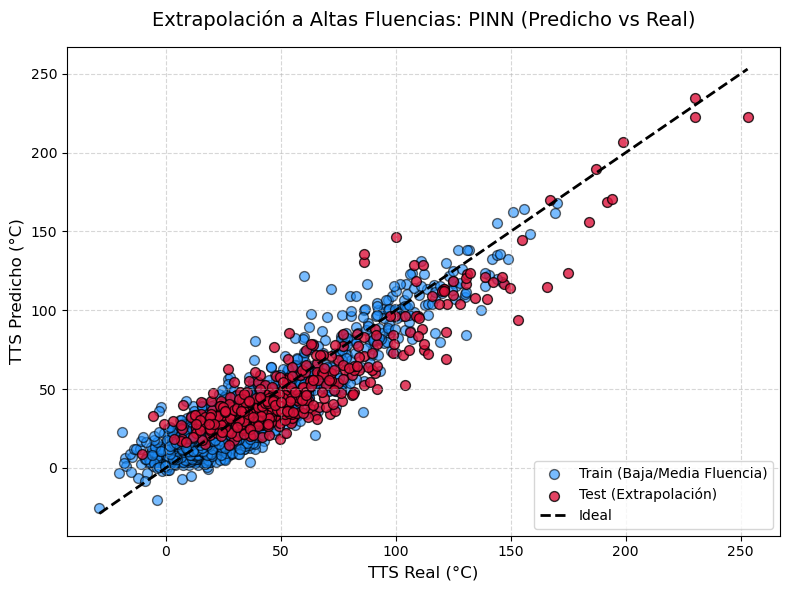

In [7]:
print("Cargando el mejor modelo PINN desde disco...")

# Instanciamos la arquitectura con los mejores parámetros
mejor_modelo = PINNEmbrittlement(
    input_dim=len(caracteristicas), 
    hidden_dim=16, 
    num_layers=3, 
    activation=nn.SiLU,
    preprocessor=scaler_completo
)

# Cargamos los pesos
ruta_modelo_05 = "../models/05_pinn_extrapolacion.pth"
mejor_modelo.load_state_dict(torch.load(ruta_modelo_05, weights_only=True))
mejor_modelo.eval() # Modo evaluación

print("✅ Modelo cargado correctamente.")

with torch.no_grad():
    # 1. Predecimos sobre Train y Test
    preds_train_scaled = mejor_modelo(X_train_tensor).numpy()
    preds_test_scaled = mejor_modelo(X_test_tensor).numpy()
    
# 2. Desescalamos para tener grados Celsius
# (Ajusta el índice 6 si 'TTS' tiene otro índice en tu scaler_completo)
mean_y = scaler_completo.mean_[6]
scale_y = scaler_completo.scale_[6]

preds_train_real = (preds_train_scaled * scale_y) + mean_y
preds_test_real = (preds_test_scaled * scale_y) + mean_y

# 3. Obtenemos los valores reales (eje X)
y_train_real = train_df[target].values.reshape(-1, 1)
y_test_real = test_df[target].values.reshape(-1, 1)

plt.figure(figsize=(8, 6))

# Dibujar TRAIN (ej. azul)
plt.scatter(y_train_real, preds_train_real, 
            color='dodgerblue', alpha=0.6, edgecolors='k', s=50, 
            label='Train (Baja/Media Fluencia)')

# Dibujar TEST (ej. rojo)
plt.scatter(y_test_real, preds_test_real, 
            color='crimson', alpha=0.8, edgecolors='k', s=50, 
            label='Test (Extrapolación)')

# Línea Ideal (x = y) calculada sobre TODOS los datos
min_val = min(y_train_real.min(), preds_train_real.min(), y_test_real.min(), preds_test_real.min())
max_val = max(y_train_real.max(), preds_train_real.max(), y_test_real.max(), preds_test_real.max())

plt.plot([min_val, max_val], [min_val, max_val], 
         color='black', linestyle='--', linewidth=2, label='Ideal')

# Formateo de la figura
plt.title('Extrapolación a Altas Fluencias: PINN (Predicho vs Real)', fontsize=14, pad=15)
plt.xlabel('TTS Real (°C)', fontsize=12)
plt.ylabel('TTS Predicho (°C)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

=== EVALUACIÓN EN ALTAS FLUENCIAS (EXTRAPOLACIÓN) ===

1. RMSE Ecuación Física: 15.245 °C
2. RMSE XGBoost: 64.086 °C
3. RMSE PINN Básica: 27.301 °C
4. RMSE PINN Extrapolación: 16.240 °C



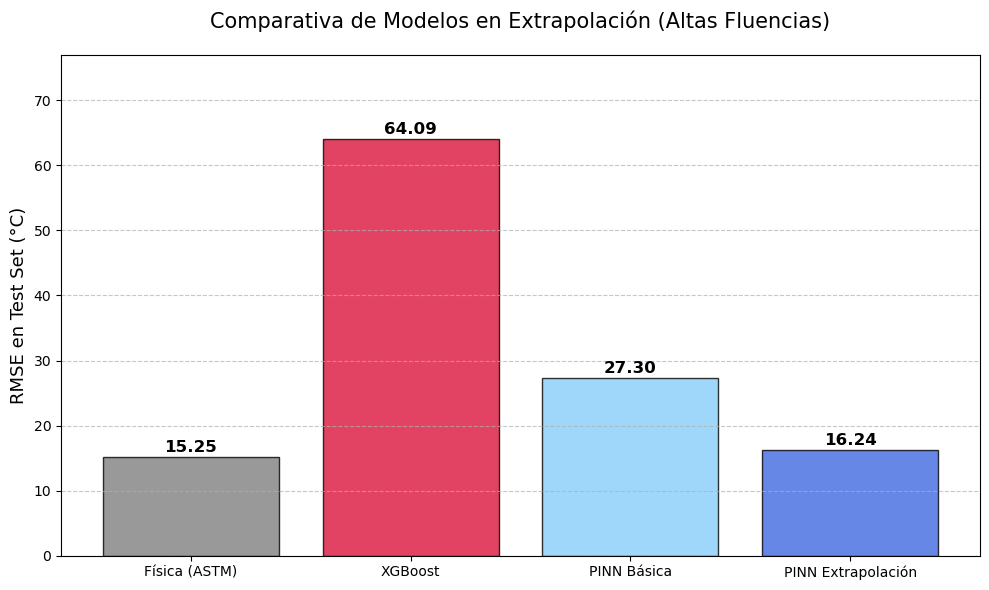

In [7]:
from src.learning.models import BaselineXGBoost, PINNEmbrittlement
import matplotlib.pyplot as plt
import numpy as np

print("=== EVALUACIÓN EN ALTAS FLUENCIAS (EXTRAPOLACIÓN) ===\n")

# Extraemos la información de escalado para devolver las predicciones a °C
mean_y = scaler_completo.mean_[6]
scale_y = scaler_completo.scale_[6]
y_test_real = test_df[target].values.reshape(-1, 1)

rmse_resultados = {}

# ---------------------------------------------------------
# 1. BASELINE FÍSICO (Ecuación ASTM E900)
# ---------------------------------------------------------
# Usamos un modelo "vacío" solo para usar su función astm_e900_pytorch
X_test_real_tensor = torch.tensor(test_df[caracteristicas].values, dtype=torch.float32)
modelo_fisico = PINNEmbrittlement(input_dim=len(caracteristicas), preprocessor=scaler_completo)

preds_baseline = modelo_fisico.astm_e900_pytorch(X_test_real_tensor).numpy()
rmse_resultados['Física (ASTM)'] = np.sqrt(mean_squared_error(y_test_real, preds_baseline))
print(f"1. RMSE Ecuación Física: {rmse_resultados['Física (ASTM)']:.3f} °C")


# ---------------------------------------------------------
# 2. XGBOOST (Aprendizaje Automático Puro)
# ---------------------------------------------------------
# Instanciamos la clase y cargamos los pesos guardados por Optuna
xgb_model = BaselineXGBoost()
xgb_model.model.load_model("../models/baselines/xgb_inicial_optuna.json")

# Le pedimos que extrapole a las Altas Fluencias (test_df)
preds_xgb = xgb_model.predict(test_df[caracteristicas].values).reshape(-1, 1)
rmse_resultados['XGBoost'] = np.sqrt(mean_squared_error(y_test_real, preds_xgb))
print(f"2. RMSE XGBoost: {rmse_resultados['XGBoost']:.3f} °C")


# ---------------------------------------------------------
# 3. PINN BÁSICA (Cargada de la libreta 03)
# ---------------------------------------------------------
# OJO: Cambia 'hidden_dim' y 'num_layers' por los que usaras en tu libreta 03
pinn_basica = PINNEmbrittlement(
    input_dim=len(caracteristicas), 
    hidden_dim=64, # <-- AJUSTAR A TU LIBRETA 03
    num_layers=3,  # <-- AJUSTAR A TU LIBRETA 03
    activation=nn.SiLU,
    preprocessor=scaler_completo
)
pinn_basica.load_state_dict(torch.load("../models/03_pinn_basica.pth", weights_only=True))
pinn_basica.eval()

with torch.no_grad():
    preds_basica_scaled = pinn_basica(X_test_tensor).numpy()
    preds_basica_real = (preds_basica_scaled * scale_y) + mean_y
    rmse_resultados['PINN Básica'] = np.sqrt(mean_squared_error(y_test_real, preds_basica_real))
print(f"3. RMSE PINN Básica: {rmse_resultados['PINN Básica']:.3f} °C")


# ---------------------------------------------------------
# 4. PINN EXTRAPOLACIÓN (Mejor modelo de esta libreta 05)
# ---------------------------------------------------------
mejor_modelo.eval()
with torch.no_grad():
    preds_extra_scaled = mejor_modelo(X_test_tensor).numpy()
    preds_extra_real = (preds_extra_scaled * scale_y) + mean_y
    rmse_resultados['PINN Extrapolación'] = np.sqrt(mean_squared_error(y_test_real, preds_extra_real))
print(f"4. RMSE PINN Extrapolación: {rmse_resultados['PINN Extrapolación']:.3f} °C\n")


# ---------------------------------------------------------
# GRÁFICA COMPARATIVA FINAL
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))
modelos = list(rmse_resultados.keys())
errores = list(rmse_resultados.values())

# Colores para diferenciar la naturaleza de los modelos
colores = ['gray', 'crimson', 'lightskyblue', 'royalblue']

barras = plt.bar(modelos, errores, color=colores, edgecolor='black', alpha=0.8)

# Añadir el valor numérico encima de cada barra
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 0.3, f"{yval:.2f}", 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Comparativa de Modelos en Extrapolación (Altas Fluencias)', fontsize=15, pad=20)
plt.ylabel('RMSE en Test Set (°C)', fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, max(errores) * 1.2) # Dejar un poco de espacio arriba

# plt.savefig("../data/img/05_comparativa_altas_fluencias.png", dpi=300)

plt.tight_layout()
plt.show()